# Introduction

Exploring multivariate relationships is an important skill to have as a data analyst or scientist. 

You might be familiar with 
* univariate (one variable)
* bivariate (two variables) analysis 

However, datasets often contain more than two features, so it’s important to be able to explore and visualize multiple variables at a time.

In this article, you will learn how to visualize multivariate relationships using:

* **Scatter plots with visual cues**
* **Grouped box plots**
* **Multi-dimensional plots**

## Scatter plots with visual cues

One way to represent multivariate relationships is to use visual cues such as 

* **colors**
* **shapes**
* **sizes** 

in a scatter plot.

 Let’s demonstrate an example using life expectancy data from the World Health Organization.

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("Life Expectancy Data.csv")

In [26]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


Meta Data:
* **Country**: name of the country
* **Year**: Year
* **Status**: Developed or Developing status
* **Life expectancy**: Life Expectancy in age
* **Adult Mortality**: Adult Mortality Rates of both sexes (probability of dying between 15 adn 60 years per 1000 population)
* **infant deaths**: Number of Infant Deaths per 1000 population
* **Alcohol**: Alcohol, recorded per captia(15+) consumption (in litres of per alchol)
* **percentage expenditure**: Expenditure on health as a percentage of Gross Domestic Product per capita(%)
* **Hepatitis B**: Hepatitis B (HepB) immunizaation coverage among 1-year-olds (%)
* **Measles**: Measles - number of reported cases per 1000 population

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

The name of data column is very confusing so we need to rename some of the columns

In [28]:
df.rename(
    columns={
        "Life expectancy ":"Life_expectancy",
        "percentage expenditure":"percentage_expenditure",
        " BMI":"BMI",
        "under-five deaths":"under_five_deaths",
        "Total expenditure":"Total_expenditure",
        " HIV/AIDS":"HIV/AIDS",
        " thinness  1-19 years":"thinness_1-19_years",
        " thinness 5-9 years":"thinness_5-9_years",
        "Income composition of resources":"Income_composition_of_resources"      
    },
    inplace=True
)

In [32]:
df.head()

,Country,Year,Status,Life_expectancy,Adult Mortality,infant deaths,Alcohol,percentage_expenditure,Hepatitis B,Measles,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness_1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Scatter plots with visual cues

Let’s create a scatter plot using Python’s seaborn library to visualize the relationship between years of education and life expectancy

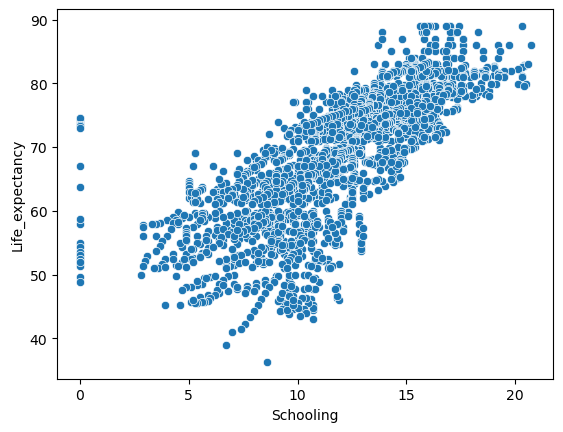

In [33]:
sns.scatterplot(x="Schooling",y="Life_expectancy",data=df)
plt.show()

It is clear from this chart that there is a **positive relationship between years of schooling and life expectancy**.

Let’s make this analysis more interesting by adding a third variable to the scatter plot using color as a visual cue. We can do this by passing in a hue argument:

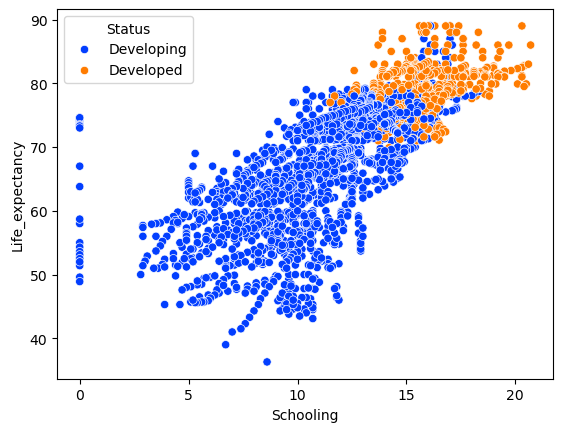

In [36]:
sns.scatterplot(x="Schooling",y="Life_expectancy",hue="Status",palette="bright", data=df)
plt.show()

This multivariate visualization provides much more insight than the bivariate visualization above. For example, we can see that:

* **Years of education** and **life expectancy** have a **positive relationship**
* Individuals in **developed** countries have **more years of schooling** than individuals in **developing** countries
* The **life expectancy** in **developed countries** is **greater** than the **life expectancy** in **developing countries**

Even though it’s possible to add more variables using additional visual cues, it’s not always a great idea to do so.

For example, let’s try adding a fourth variable to this visualization using shapes as a visual cue:

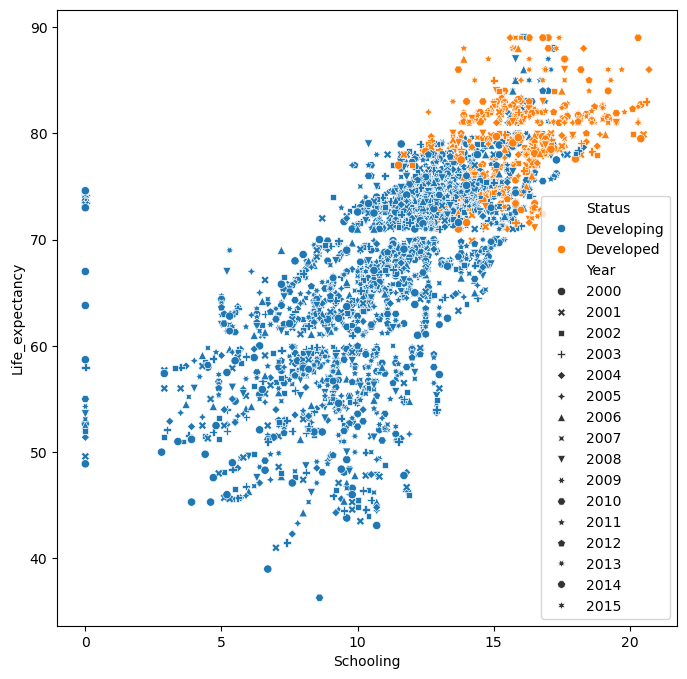

In [40]:
plt.figure(figsize=(8,8))
sns.scatterplot(x="Schooling",y="Life_expectancy",hue="Status",style="Year",data=df)
plt.show()

This chart is overloaded with information and is difficult to read. You always want to make sure your charts are readable and easy to interpret. 

Generally, anything beyond three variables in a scatter plot is probably too much for the human eye to process.

## Grouped box plots

Grouped box plots can be used to **visualize two categorical variables and a quantitative variable**. Having the box plots side-by-side can help you gain useful insights.

For example, let’s take a look at Stack Overflow’s Developer Survey data to learn more about how salary is related to education level and gender.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
salary_data = pd.read_csv('survey_results_public.csv')

In [11]:
salary_data.head()

,ResponseId,MainBranch,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,...,TimeSearching,TimeAnswering,Onboarding,ProfessionalTech,TrueFalse_1,TrueFalse_2,TrueFalse_3,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,None of these,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,"Employed, full-time",Fully remote,Hobby;Contribute to open-source projects,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Difficult,NaN
2,3,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Friend or family member...,Technical documentation;Blogs;Programming Game...,NaN,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,40205.0
3,4,I am a developer by profession,"Employed, full-time",Fully remote,I don’t code outside of work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;School (i.e., Universit...",NaN,NaN,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,215232.0
4,5,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Stack Overflow;O...,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN


In [12]:
salary_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73268 entries, 0 to 73267
Data columns (total 79 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ResponseId                      73268 non-null  int64  
 1   MainBranch                      73268 non-null  object 
 2   Employment                      71709 non-null  object 
 3   RemoteWork                      58958 non-null  object 
 4   CodingActivities                58899 non-null  object 
 5   EdLevel                         71571 non-null  object 
 6   LearnCode                       71580 non-null  object 
 7   LearnCodeOnline                 50685 non-null  object 
 8   LearnCodeCoursesCert            29389 non-null  object 
 9   YearsCode                       71331 non-null  object 
 10  YearsCodePro                    51833 non-null  object 
 11  DevType                         61302 non-null  object 
 12  OrgSize                         

Next, let’s create a box plot to show the **relationship between education and compensation**:

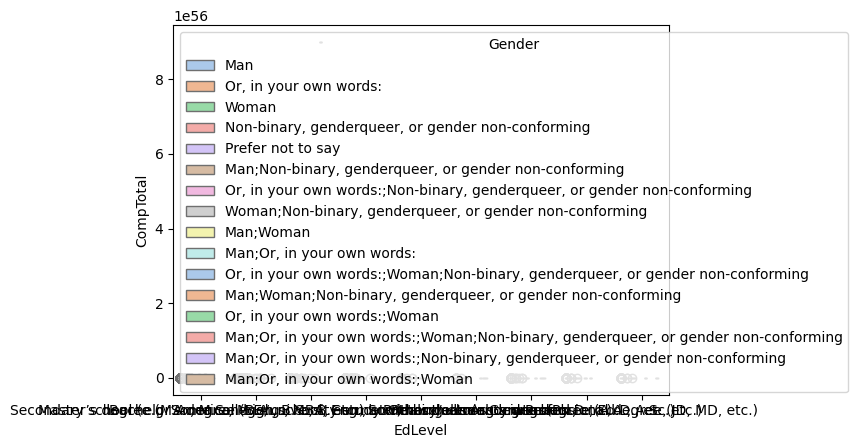

In [35]:
sns.boxplot(x = "EdLevel", y = "CompTotal", hue = "Gender", palette = "pastel", data = salary_data)
plt.show()